# Steerable Convolution: Basis Functions and the Tensor Product Structure of Filters

**6.7970/8.750 Symmetry and its Application to Machine Learning**

This notebook accompanies the [Steerable Convolution notes](https://symm4ml.mit.edu/notes/steerable-convolution). We'll:

1. Decompose the pixel permutation representation into spatial basis functions
2. Explore what happens when we tensor product these with additional representations
3. Build up to the full $\Gamma^{\text{reg}} \otimes \Gamma^{\text{pix}}$ filter space of group convolution
4. Understand $D^{\text{reg}}$ as a coupling tensor

In [ ]:
%%capture
!pip install torch
!pip install https://symm4ml.mit.edu/_static/symm4ml_s26/symm4ml/symm4ml_latest.zip

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from symm4ml import groups, rep, linalg, group_conv

# Build D4 group
rot90 = np.array([[np.cos(np.pi/2), -np.sin(np.pi/2)],
                  [np.sin(np.pi/2),  np.cos(np.pi/2)]])
sigma_v = np.array([[-1., 0.], [0., 1.]])

D4 = np.array(groups.generate_group(np.array([sigma_v, rot90]))[::-1])  # E first
D4_table = groups.make_multiplication_table(D4)
D4_torch = torch.tensor(D4, dtype=torch.float32)
D4_reg_rep = rep.regular_representation(D4_table)

# Get irreps
np.random.seed(0)
D4_irreps = rep.infer_irreps(D4_table)  # 5 irreps (possibly complex, arbitrary basis)

# We can choose a basis such that all D4 irreps are real, for example where
# the E irrep matrices are the rotation and reflection matrices on (x, y).
# infer_irreps returns E in an arbitrary basis, so we replace it with the
# geometric vector representation — the 2x2 matrices of D4 themselves.
E_idx = next(i for i, ir in enumerate(D4_irreps) if ir.shape[1] == 2)

# Confirm the random-basis E is isomorphic to the vec rep before replacing
S = linalg.infer_change_of_basis(D4_irreps[E_idx], D4)
print(f'Random-basis E isomorphic to vec rep? {S.shape[0] > 0}')

# Cast all to real and replace E with vec rep
D4_irreps = [ir.real for ir in D4_irreps]
D4_irreps[E_idx] = D4.copy()

# Label the 1D irreps using the standard D4 character table.
# A1: χ=+1 for all g.  A2: χ=+1 on rotations, -1 on reflections.
# B1, B2: χ=-1 on C4 rotations; B1 has χ=+1 on σ_v, B2 has χ=-1 on σ_v.
dets = np.array([np.linalg.det(D4[g]) for g in range(len(D4))])
is_rot = dets > 0
irrep_labels = [None] * 5
for i, ir in enumerate(D4_irreps):
    if ir.shape[1] == 2:
        irrep_labels[i] = 'E'
    elif ir.shape[1] == 1:
        vals = ir[:, 0, 0]
        if np.allclose(vals, 1):
            irrep_labels[i] = 'A1'
        elif np.allclose(vals[is_rot], 1) and np.allclose(vals[~is_rot], -1):
            irrep_labels[i] = 'A2'
        else:
            # B1 vs B2: check sign on σ_v (g=1 is sigma_v for our ordering)
            if vals[1] > 0:
                irrep_labels[i] = 'B1'
            else:
                irrep_labels[i] = 'B2'

print(f'D4: {len(D4)} elements')
print(f'Irreps: {list(zip(irrep_labels, [ir.shape[1] for ir in D4_irreps]))}')

Random-basis E isomorphic to vec rep? True
D4: 8 elements
Irreps: [('A1', 1), ('B2', 1), ('B1', 1), ('A2', 1), ('E', 2)]


---
## 1. Spatial Basis Functions

A $3 \times 3$ kernel has 9 pixels. Under $D_4$, these pixels are permuted — giving a 9-dimensional permutation representation $\Gamma^{\text{pix}}$. This is the same kind of permutation representation we used in vibrational modes to describe how symmetry operations permute atomic sites.

### Build the pixel permutation representation

In [2]:
# Build the 9x9 permutation representation for 3x3 kernel under D4
perm_rep = group_conv.image2D_permutation_representation(D4_torch, [3, 3]).numpy()
print(f'Pixel permutation rep shape: {perm_rep.shape}')  # (8, 9, 9)

# Verify: each matrix is a permutation matrix
print(f'All permutation matrices? {all(np.allclose(p @ p.T, np.eye(9)) for p in perm_rep)}')

Pixel permutation rep shape: (8, 9, 9)
All permutation matrices? True


### Decompose into irreps

We use `linalg.infer_change_of_basis` — the same tool from the decomposition exercises — to find how each irrep embeds in $\Gamma^{\text{pix}}$.

In [3]:
# Decompose the pixel perm rep into irreps
spatial_basis = []
print('Decomposition of Gamma^pix:')
print(f'{"Irrep":<6} {"dim":<5} {"copies":<7} {"total"}')
print('-' * 30)
total = 0
for label, irrep in zip(irrep_labels, D4_irreps):
    d = irrep.shape[1]
    S = linalg.infer_change_of_basis(irrep, perm_rep)  # This is the important part!
    n_copies = S.shape[0]
    if n_copies > 0:
        S = S.real
        # infer_change_of_basis normalizes the flattened (d × pixels) vector to unit norm.
        # For a d-dimensional irrep, this means each component row has norm 1/√d.
        # Scale each copy by √d so that individual basis functions are unit-normalized.
        # This preserves the intertwining relation since all rows within a copy
        # have equal norms (guaranteed by the orthogonality of the irrep matrices).
        S = S * np.sqrt(d)
        spatial_basis.append(S)
    else:
        spatial_basis.append(np.zeros((0, d, 9)))
    subtotal = n_copies * d
    total += subtotal
    print(f'{label:<6} {d:<5} {n_copies:<7} {subtotal}')
print('-' * 30)
print(f'Total: {total} = 9 pixels ✓')

Decomposition of Gamma^pix:
Irrep  dim   copies  total
------------------------------
A1     1     3       3
B2     1     1       1
B1     1     1       1
A2     1     0       0
E      2     2       4
------------------------------
Total: 9 = 9 pixels ✓


### Visualize the 9 basis functions

Each basis function is a specific $3 \times 3$ pattern that transforms as an irrep of $D_4$. Compare with the character table:
- $A_1 \leftrightarrow$ constant (isotropic)
- $B_1 \leftrightarrow x^2 - y^2$
- $B_2 \leftrightarrow xy$
- $E \leftrightarrow (x, y)$
- $A_2$: zero copies (would need $\geq 5 \times 5$ kernel)

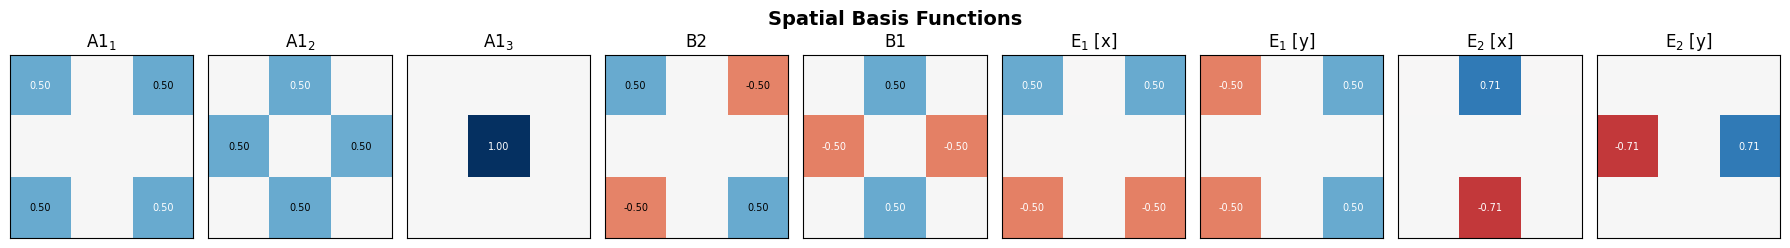

In [4]:
def plot_basis_functions(spatial_basis, irrep_labels, title='Spatial Basis Functions'):
    """Visualize all basis functions as 3x3 grids."""
    # Count total number of individual basis function components
    all_patterns = []
    all_labels = []
    for label, sb in zip(irrep_labels, spatial_basis):
        if sb.shape[0] == 0:
            continue
        n_copies, d, n_pix = sb.shape
        for copy in range(n_copies):
            for comp in range(d):
                pattern = sb[copy, comp].reshape(3, 3)
                sublabel = f'{label}'
                if n_copies > 1:
                    sublabel += f'$_{{{copy+1}}}$'
                if d > 1:
                    sublabel += f' [{"x" if comp == 0 else "y"}]'
                all_patterns.append(pattern)
                all_labels.append(sublabel)
    
    n = len(all_patterns)
    fig, axes = plt.subplots(1, n, figsize=(2*n, 2.5))
    if n == 1:
        axes = [axes]
    
    vmax = max(np.abs(p).max() for p in all_patterns)
    for ax, pattern, label in zip(axes, all_patterns, all_labels):
        ax.imshow(pattern, cmap='RdBu', vmin=-vmax, vmax=vmax,
                  interpolation='nearest')
        ax.set_title(label, fontsize=12)
        ax.set_xticks([])
        ax.set_yticks([])
        # Annotate values
        for i in range(3):
            for j in range(3):
                val = pattern[i, j]
                if abs(val) > 0.01:
                    ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                            fontsize=7, color='white' if abs(val) > vmax*0.5 else 'black')
    
    fig.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    return fig

fig = plot_basis_functions(spatial_basis, irrep_labels)

### Verify orthogonality (the selection rule)

Basis functions from different irreps (or different copies/components) are orthogonal:

Orthonormal? True


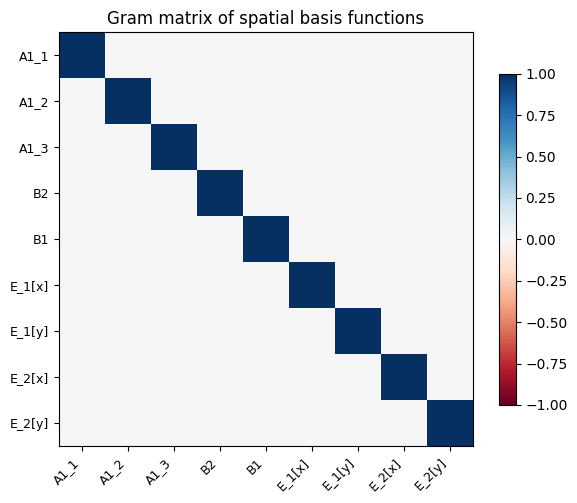

In [5]:
# Verify orthogonality: all 9 basis functions should form an orthonormal set
all_basis = []
all_labels_flat = []
for label, sb in zip(irrep_labels, spatial_basis):
    if sb.shape[0] == 0:
        continue
    n_copies, d, n_pix = sb.shape
    for copy in range(n_copies):
        for comp in range(d):
            all_basis.append(sb[copy, comp])
            sublabel = label
            if n_copies > 1:
                sublabel += f'_{copy+1}'
            if d > 1:
                sublabel += f'[{"x" if comp == 0 else "y"}]'
            all_labels_flat.append(sublabel)

all_basis = np.array(all_basis)  # (9, 9)
gram = all_basis @ all_basis.T

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(gram, cmap='RdBu', vmin=-1, vmax=1)
ax.set_xticks(range(len(all_labels_flat)))
ax.set_yticks(range(len(all_labels_flat)))
ax.set_xticklabels(all_labels_flat, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(all_labels_flat, fontsize=9)
ax.set_title('Gram matrix of spatial basis functions')
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()

print(f'Orthonormal? {np.allclose(gram, np.eye(9), atol=1e-6)}')

---
## 2. Tensor Product: Enriching the Filter Space

The spatial basis functions span 9 dimensions with irreps $3A_1 \oplus B_1 \oplus B_2 \oplus 2E$. Notice: **no $A_2$**.

In group convolution, the filter $\psi_j(\mathbf{y})$ has a group index $j$ that carries $\Gamma^{\text{reg}}$. The full filter space is $\Gamma^{\text{pix}} \otimes \Gamma^{\text{reg}}$ — the tensor product creates richer basis elements that span ALL irreps.

Before jumping to the full reg rep, let's explore a smaller tensor product.

### Warm-up: $\Gamma^{\text{pix}} \otimes (A_2 \oplus E)$

What happens if we tensor the pixel basis with $A_2 \oplus E$ (dimension 3)?

In [6]:
# Build the representation A2 ⊕ E
# Look up by label, not by hardcoded index
A2_idx = irrep_labels.index('A2')
E_idx = irrep_labels.index('E')
A2_rep = D4_irreps[A2_idx]  # shape (8, 1, 1)
E_rep = D4_irreps[E_idx]    # shape (8, 2, 2)

# Direct sum: A2 ⊕ E → 3x3 block-diagonal matrices
rho_extra = np.zeros((len(D4), 3, 3))
rho_extra[:, 0:1, 0:1] = A2_rep
rho_extra[:, 1:3, 1:3] = E_rep

print(f'ρ_extra shape: {rho_extra.shape}')  # (8, 3, 3)
print(f'Dimension: {rho_extra.shape[1]} = dim(A2) + dim(E) = 1 + 2')

ρ_extra shape: (8, 3, 3)
Dimension: 3 = dim(A2) + dim(E) = 1 + 2


In [7]:
# Tensor product: Gamma^pix ⊗ (A2 ⊕ E)
tp_small = rep.tensor_product(perm_rep, rho_extra)
print(f'Tensor product dimension: {tp_small.shape[1]} = 9 × 3 = 27')

# Decompose into irreps
print(f'\nDecomposition of Γ^pix ⊗ (A2 ⊕ E):')
print(f'{"Irrep":<6} {"dim":<5} {"copies":<7} {"total"}')
print('-' * 30)
total = 0
tp_small_basis = {}
for label, irrep in zip(irrep_labels, D4_irreps):
    d = irrep.shape[1]
    S = linalg.infer_change_of_basis(irrep, tp_small)
    n_copies = S.shape[0]
    tp_small_basis[label] = S.real if n_copies > 0 else np.zeros((0, d, 27))
    subtotal = n_copies * d
    total += subtotal
    marker = ' ← NEW!' if label == 'A2' and n_copies > 0 else ''
    print(f'{label:<6} {d:<5} {n_copies:<7} {subtotal}{marker}')
print('-' * 30)
print(f'Total: {total} = 27 ✓')
print(f'\nA2 now appears! The extra rep supplies the missing irrep.')

Tensor product dimension: 27 = 9 × 3 = 27

Decomposition of Γ^pix ⊗ (A2 ⊕ E):
Irrep  dim   copies  total
------------------------------
A1     1     2       2
B2     1     3       3
B1     1     3       3
A2     1     5       5 ← NEW!
E      2     7       14
------------------------------
Total: 27 = 27 ✓

A2 now appears! The extra rep supplies the missing irrep.


### Where do the $A_2$ copies come from?

Let's trace them through the CG decomposition:

In [8]:
# Trace where A2 copies come from in pix ⊗ (A2 ⊕ E)
print('Sources of A2 in Γ^pix ⊗ (A2 ⊕ E):\n')

pix_decomp = {'A1': 3, 'A2': 0, 'B1': 1, 'B2': 1, 'E': 2}
extra_irreps = ['A2', 'E']

# CG products that give A2
# A1 ⊗ A2 = A2, B1 ⊗ B2 = A2, B2 ⊗ B1 = A2, E ⊗ E ⊃ A2
cg_to_A2 = {
    ('A1', 'A2'): 1, ('A2', 'A1'): 1,
    ('B1', 'B2'): 1, ('B2', 'B1'): 1,
    ('E', 'E'): 1,  # E ⊗ E = A1+A2+B1+B2, one A2
}

a2_count = 0
for pix_ir, pix_copies in pix_decomp.items():
    if pix_copies == 0:
        continue
    for ext_ir in extra_irreps:
        key = (pix_ir, ext_ir)
        if key in cg_to_A2:
            n = pix_copies * cg_to_A2[key]
            if ext_ir == 'E':  # E has multiplicity 1 in rho_extra
                n = pix_copies * 1
            print(f'  {pix_ir}(pix) ⊗ {ext_ir}(extra) → A2:  {pix_copies} × {cg_to_A2[key]} = {n} copies')
            a2_count += n

print(f'\nTotal A2 copies: {a2_count}')

Sources of A2 in Γ^pix ⊗ (A2 ⊕ E):

  A1(pix) ⊗ A2(extra) → A2:  3 × 1 = 3 copies
  E(pix) ⊗ E(extra) → A2:  2 × 1 = 2 copies

Total A2 copies: 5


---
## 3. Full Tensor Product: $\Gamma^{\text{pix}} \otimes \Gamma^{\text{reg}}$

Now let's do the full group conv case. The filter lives in $\Gamma^{\text{pix}} \otimes \Gamma^{\text{reg}}$, dimension $9 \times 8 = 72$.

The regular representation $\Gamma^{\text{reg}} = A_1 \oplus A_2 \oplus B_1 \oplus B_2 \oplus 2E$ contains **every irrep** — so the tensor product will contain all possible coupling paths.

In [9]:
# Full tensor product: pix ⊗ reg
tp_full = rep.tensor_product(perm_rep, D4_reg_rep)
print(f'Full tensor product dimension: {tp_full.shape[1]} = 9 × 8 = 72')

# Decompose
print(f'\nDecomposition of Γ^pix ⊗ Γ^reg:')
print(f'{"Irrep":<6} {"dim":<5} {"copies":<7} {"total"}')
print('-' * 30)
total = 0
tp_full_basis = []
for label, irrep in zip(irrep_labels, D4_irreps):
    d = irrep.shape[1]
    S = linalg.infer_change_of_basis(irrep, tp_full)
    n_copies = S.shape[0]
    tp_full_basis.append(S.real if n_copies > 0 else np.zeros((0, d, 72)))
    subtotal = n_copies * d
    total += subtotal
    print(f'{label:<6} {d:<5} {n_copies:<7} {subtotal}')
print('-' * 30)
print(f'Total: {total} = 72 = |G| × pixels ✓')

Full tensor product dimension: 72 = 9 × 8 = 72

Decomposition of Γ^pix ⊗ Γ^reg:
Irrep  dim   copies  total
------------------------------
A1     1     9       9
B2     1     9       9
B1     1     9       9
A2     1     9       9
E      2     18      36
------------------------------
Total: 72 = 72 = |G| × pixels ✓


In [10]:
tp_full_basis[0].shape

(9, 1, 72)

### Where do the 9 copies of $A_2$ come from?

Let's trace every (pixel irrep) $\otimes$ (reg rep irrep) pair that produces $A_2$:

In [11]:
# Trace A2 sources in pix ⊗ reg
reg_decomp = {'A1': 1, 'A2': 1, 'B1': 1, 'B2': 1, 'E': 2}

print('Sources of A2 in Γ^pix ⊗ Γ^reg:\n')
a2_count = 0
for pix_ir, pix_copies in pix_decomp.items():
    if pix_copies == 0:
        continue
    for reg_ir, reg_copies in reg_decomp.items():
        key = (pix_ir, reg_ir)
        if key in cg_to_A2:
            n = pix_copies * reg_copies * cg_to_A2[key]
            print(f'  {pix_ir}(pix, {pix_copies}×) ⊗ {reg_ir}(reg, {reg_copies}×) → A2:  '
                  f'{pix_copies} × {reg_copies} × {cg_to_A2[key]} = {n} copies')
            a2_count += n

print(f'\nTotal A2 copies: {a2_count}')
print(f'\nThe reg rep provides the "missing" A2 through tensor products!')

Sources of A2 in Γ^pix ⊗ Γ^reg:

  A1(pix, 3×) ⊗ A2(reg, 1×) → A2:  3 × 1 × 1 = 3 copies
  B1(pix, 1×) ⊗ B2(reg, 1×) → A2:  1 × 1 × 1 = 1 copies
  B2(pix, 1×) ⊗ B1(reg, 1×) → A2:  1 × 1 × 1 = 1 copies
  E(pix, 2×) ⊗ E(reg, 2×) → A2:  2 × 2 × 1 = 4 copies

Total A2 copies: 9

The reg rep provides the "missing" A2 through tensor products!


### Visualize the basis elements

Use the dropdown menus to explore the basis elements by irrep. The **Spatial** tab shows the 9 basis functions from $\Gamma^{\text{pix}}$ alone. The **$\Gamma^{\text{pix}} \otimes \Gamma^{\text{reg}}$** tab shows the 72 basis elements of the full group conv filter space — each visualized as 8 copies of a $3 \times 3$ pattern (one per group element, in character table order).

In [12]:
from IPython.display import HTML
import json as _json

# Label group elements
_g_labels = []
for g in range(8):
    m = D4[g]; det = np.linalg.det(m)
    if np.allclose(m, np.eye(2)): _g_labels.append('E')
    elif np.allclose(m, -np.eye(2)): _g_labels.append('C\u2082')
    elif det > 0: _g_labels.append('C\u2084' if m[1,0] > 0 else 'C\u2084\u00b3')
    else:
        eigvals, eigvecs = np.linalg.eig(m.astype(float))
        axis = eigvecs[:, np.argmin(np.abs(eigvals - 1))].real
        angle = np.degrees(np.arctan2(axis[1], axis[0])) % 180
        if angle < 10 or angle > 170: _g_labels.append('\u03c3\u1d65(x)')
        elif abs(angle - 90) < 10: _g_labels.append('\u03c3\u1d65(y)')
        elif abs(angle - 45) < 10: _g_labels.append('\u03c3\u1d48(xy)')
        else: _g_labels.append('\u03c3\u1d48(x\u0304y)')

# Character table order
_char_order = [0, 4, 3, 7, 1, 6, 2, 5]
_sorted_labels = [_g_labels[g] for g in _char_order]

# Prepare data
_tp_data = {}
for label, sb in zip(irrep_labels, tp_full_basis):
    if sb.shape[0] > 0:
        n, d, _ = sb.shape
        s = sb.real.reshape(n, d, 9, 8)[:, :, :, _char_order]
        s = s.transpose(0, 1, 3, 2).reshape(n, d, 72)
        _tp_data[label] = {'copies': int(n), 'dim': int(d), 'data': s.tolist()}
    else:
        _tp_data[label] = {'copies': 0, 'dim': int(sb.shape[1]), 'data': []}

_sp_data = {}
for label, sb in zip(irrep_labels, spatial_basis):
    if sb.shape[0] > 0:
        _sp_data[label] = {'copies': int(sb.shape[0]), 'dim': int(sb.shape[1]), 'data': sb.tolist()}
    else:
        _sp_data[label] = {'copies': 0, 'dim': int(sb.shape[1]), 'data': []}

_widget_json = _json.dumps({
    'spatial': _sp_data, 'tp_full': _tp_data,
    'irrep_order': ['A1', 'A2', 'B1', 'B2', 'E'],
    'group_labels': _sorted_labels,
})

# Read the standalone HTML file and inject data
# Use string concatenation, NOT f-strings, to avoid curly brace conflicts
_html = """<style>
.bf-controls { display: flex; gap: 12px; align-items: center; margin-bottom: 8px; }
.bf-controls label { font-size: 14px; font-weight: 600; }
.bf-controls select { font-size: 14px; padding: 3px 6px; }
.bf-info { font-size: 14px; color: #555; margin-bottom: 10px; }
.bf-info b { color: #6a00a8; }
.bf-row { display: flex; align-items: center; gap: 4px; margin-bottom: 5px; }
.bf-lbl { width: 65px; font-size: 12px; font-weight: 600; color: #555; text-align: right; padding-right: 6px; flex-shrink: 0; }
.bf-grid { display: inline-grid; grid-template-columns: repeat(3, 22px); grid-template-rows: repeat(3, 22px); gap: 1px; border: 1px solid #ccc; border-radius: 3px; overflow: hidden; }
.bf-px { display: flex; align-items: center; justify-content: center; font-size: 8px; font-weight: 600; }
.bf-slot { display: inline-flex; flex-direction: column; align-items: center; gap: 2px; width: 70px; flex-shrink: 0; }
.bf-gl { font-size: 11px; font-weight: 500; color: #555; }
.bf-tab { display: flex; gap: 0; margin-bottom: 0; }
.bf-tb { padding: 6px 14px; font-size: 14px; font-weight: 600; border: 1px solid #ccc; border-bottom: none; border-radius: 6px 6px 0 0; background: #f5f5f5; color: #888; cursor: pointer; }
.bf-tb.active { background: white; color: #6a00a8; border-bottom: 1px solid white; margin-bottom: -1px; z-index: 1; }
.bf-tc { border: 1px solid #ccc; border-radius: 0 6px 6px 6px; padding: 12px; background: white; min-height: 150px; }
.bf-sep { margin-left: 65px; height: 1px; background: #e0d0f0; margin: 3px 0; }
</style>
<div class="bf-tab">
  <button class="bf-tb active" onclick="bfSwitch('sp')">Spatial (&Gamma;<sup>pix</sup>)</button>
  <button class="bf-tb" onclick="bfSwitch('tp')">&Gamma;<sup>pix</sup> &otimes; &Gamma;<sup>reg</sup> (72 params)</button>
</div>
<div class="bf-tc" id="bf-sp">
  <div class="bf-controls"><label>Irrep:</label><select id="bf-sel-sp" onchange="bfRSp()"></select></div>
  <div class="bf-info" id="bf-isp"></div><div id="bf-vsp"></div>
</div>
<div class="bf-tc" id="bf-tp" style="display:none">
  <div class="bf-controls"><label>Irrep:</label><select id="bf-sel-tp" onchange="bfUCp();bfRTp()"></select>
  <label style="margin-left:12px">Copy:</label><select id="bf-sel-cp" onchange="bfRTp()"></select></div>
  <div class="bf-info" id="bf-itp"></div><div id="bf-vtp"></div>
</div>
<script>
const BF=""" + _widget_json + """;
const BO=BF.irrep_order, BGL=BF.group_labels;
function bfC(v,mx){if(mx<1e-10)return'rgb(240,240,240)';const t=Math.max(-1,Math.min(1,v/mx));if(t<0){const f=-t;return`rgb(${Math.round(240+f*(106-240))},${Math.round(240+f*(0-240))},${Math.round(240+f*(168-240))})`}else{const f=t;return`rgb(${Math.round(240+f*(230-240))},${Math.round(240+f*(81-240))},${Math.round(240+f*(0-240))})`}}
function bfG(vals,mx,lg){let h='<div class="bf-grid"'+(lg?' style="grid-template-columns:repeat(3,26px);grid-template-rows:repeat(3,26px)"':'')+'>';for(let i=0;i<9;i++){const v=vals[i],bg=bfC(v,mx),tc=(mx>1e-10&&Math.abs(v/mx)>0.4)?'#fff':'#333',tx=Math.abs(v)>0.005?v.toFixed(2):'';h+=`<div class="bf-px" style="background:${bg};color:${tc}">${tx}</div>`}return h+'</div>'}
function bfInit(){const s1=document.getElementById('bf-sel-sp'),s2=document.getElementById('bf-sel-tp');s1.innerHTML='';s2.innerHTML='';BO.forEach(l=>{let o=document.createElement('option');o.value=l;o.textContent=`${l} (${BF.spatial[l].copies} copies, dim ${BF.spatial[l].dim})`;s1.appendChild(o);o=document.createElement('option');o.value=l;o.textContent=`${l} (${BF.tp_full[l].copies} copies, dim ${BF.tp_full[l].dim})`;s2.appendChild(o)});bfUCp();bfRSp();bfRTp()}
function bfRSp(){const l=document.getElementById('bf-sel-sp').value,info=BF.spatial[l],id=document.getElementById('bf-isp'),vd=document.getElementById('bf-vsp');if(!info.copies){id.innerHTML=`<b>${l}</b>: 0 copies — no basis function on 3×3.`;vd.innerHTML='';return}id.innerHTML=`<b>${l}</b>: ${info.copies} copies × dim ${info.dim} = ${info.copies*info.dim} basis functions.`;let h='',mx=0;for(let c=0;c<info.copies;c++)for(let k=0;k<info.dim;k++)for(let p=0;p<9;p++)mx=Math.max(mx,Math.abs(info.data[c][k][p]));for(let c=0;c<info.copies;c++){for(let k=0;k<info.dim;k++){const cl=info.dim>1?(k===0?' [x]':' [y]'):'',cp=info.copies>1?`copy ${c+1}`:'';h+=`<div class="bf-row"><div class="bf-lbl">${cp}${cl}</div>${bfG(info.data[c][k],mx,true)}</div>`}if(c<info.copies-1&&info.dim>1)h+='<div class="bf-sep"></div>'}vd.innerHTML=h}
function bfUCp(){const info=BF.tp_full[document.getElementById('bf-sel-tp').value],s=document.getElementById('bf-sel-cp');s.innerHTML='';let o=document.createElement('option');o.value='all';o.textContent=`All ${info.copies} copies`;s.appendChild(o);for(let c=0;c<info.copies;c++){o=document.createElement('option');o.value=c;o.textContent=`Copy ${c+1}`;s.appendChild(o)}}
function bfRTp(){const l=document.getElementById('bf-sel-tp').value,cv=document.getElementById('bf-sel-cp').value,info=BF.tp_full[l],id=document.getElementById('bf-itp'),vd=document.getElementById('bf-vtp');if(!info.copies){id.innerHTML=`<b>${l}</b>: 0 copies.`;vd.innerHTML='';return}id.innerHTML=`<b>${l}</b>: ${info.copies} copies × dim ${info.dim} = ${info.copies*info.dim} of 72 params.`;const copies=cv==='all'?[...Array(info.copies).keys()]:[parseInt(cv)];let h='<div class="bf-row"><div class="bf-lbl"></div>';for(let g=0;g<8;g++)h+=`<div class="bf-slot"><div class="bf-gl">${BGL[g]}</div></div>`;h+='</div>';let mx=0;copies.forEach(c=>{for(let k=0;k<info.dim;k++)for(let p=0;p<72;p++)mx=Math.max(mx,Math.abs(info.data[c][k][p]))});copies.forEach(c=>{for(let k=0;k<info.dim;k++){const cl=info.dim>1?(k===0?' [x]':' [y]'):'';h+=`<div class="bf-row"><div class="bf-lbl">copy ${c+1}${cl}</div>`;for(let g=0;g<8;g++)h+=`<div class="bf-slot">${bfG(info.data[c][k].slice(g*9,(g+1)*9),mx,false)}</div>`;h+='</div>'}if(copies.length>1)h+='<div class="bf-sep"></div>'});vd.innerHTML=h}
function bfSwitch(w){document.querySelectorAll('.bf-tb').forEach(b=>b.classList.remove('active'));document.getElementById('bf-sp').style.display=w==='sp'?'':'none';document.getElementById('bf-tp').style.display=w==='tp'?'':'none';document.querySelectorAll('.bf-tb')[w==='sp'?0:1].classList.add('active')}
bfInit();
</script>"""

HTML(_html)

---
## 4. $D^{\text{reg}}$ as a Coupling Tensor

In the group conv formula:

$$[f \star \psi]_k(\mathbf{x}) = \sum_{\mathbf{y}} \sum_{i,j} f_i(\mathbf{x} + k\mathbf{y})\, \psi_j(\mathbf{y})\, D^{\text{reg}}(k)_{ij}$$

$D^{\text{reg}}(k)_{ij}$ is a **coupling tensor**: it takes two inputs ($f_i$ and $\psi_j$) and produces an output indexed by $k$. Same structural role as CG coefficients, but in the group element basis.

Let's verify: the reg rep is the "universal" coupling tensor because it contains every irrep.

Q_G shape: (8, 8)
Q_G orthogonal? True


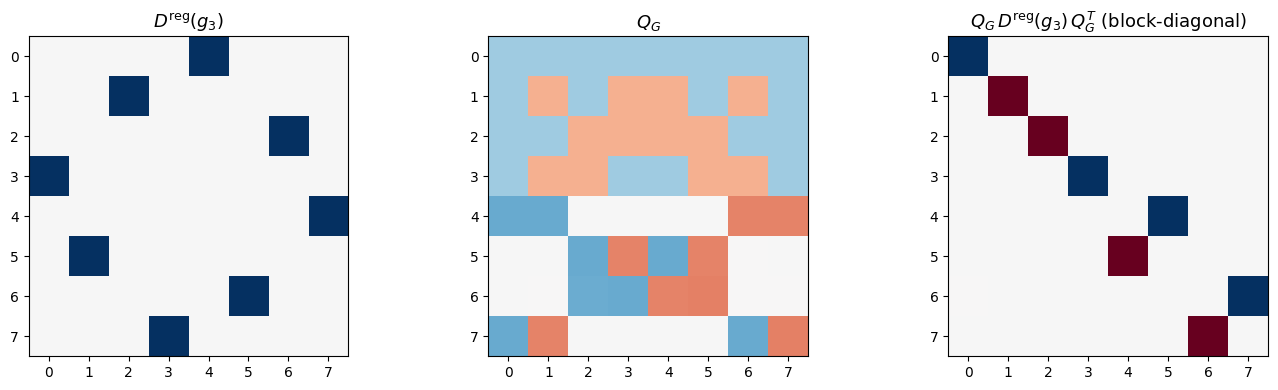

In [13]:
# Build Q_G: the change-of-basis that block-diagonalizes the reg rep
# For each irrep, find how it embeds in the regular rep
Q_rows = []
Q_slices = []
Q_labels = []
pos = 0
for label, irrep in zip(irrep_labels, D4_irreps):
    d = irrep.shape[1]
    S = linalg.infer_change_of_basis(irrep, D4_reg_rep)
    for m in range(S.shape[0]):
        block, _ = linalg.gram_schmidt(S[m])
        Q_rows.append(block)
        Q_slices.append((pos, pos + d, d))
        Q_labels.append(f'{label}_{m+1}' if S.shape[0] > 1 else label)
        pos += d

Q_G = np.concatenate(Q_rows, axis=0)
print(f'Q_G shape: {Q_G.shape}')
print(f'Q_G orthogonal? {np.allclose(Q_G @ Q_G.T, np.eye(8), atol=1e-6)}')

########## CHANGE ME!!!!!! ##########
# Show that D^reg block-diagonalizes via Q_G
g = 3  # pick a non-trivial group element
D_reg_g = D4_reg_rep[g]
block_diag = Q_G @ D_reg_g @ Q_G.T

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].imshow(D_reg_g, cmap='RdBu', vmin=-1, vmax=1)
axes[0].set_title(f'$D^{{\\text{{reg}}}}(g_{{{g}}})$', fontsize=13)

axes[1].imshow(Q_G, cmap='RdBu', vmin=-1, vmax=1)
axes[1].set_title('$Q_G$', fontsize=13)

axes[2].imshow(block_diag, cmap='RdBu', vmin=-1, vmax=1)
axes[2].set_title(f'$Q_G \\, D^{{\\text{{reg}}}}(g_{{{g}}}) \\, Q_G^T$ (block-diagonal)', fontsize=13)

for ax in axes:
    ax.set_xticks(range(8))
    ax.set_yticks(range(8))

plt.tight_layout()

In [14]:
# Show the irrep blocks
print('Irrep blocks in the block-diagonalized reg rep:\n')
for label, (start, end, dim) in zip(Q_labels, Q_slices):
    block = block_diag[start:end, start:end]
    print(f'{label} (rows {start}-{end-1}, dim {dim}):')
    print(np.round(block, 3))
    print()

Irrep blocks in the block-diagonalized reg rep:

A1 (rows 0-0, dim 1):
[[1.]]

B2 (rows 1-1, dim 1):
[[-1.]]

B1 (rows 2-2, dim 1):
[[-1.]]

A2 (rows 3-3, dim 1):
[[1.]]

E_1 (rows 4-5, dim 2):
[[ 0.  1.]
 [-1.  0.]]

E_2 (rows 6-7, dim 2):
[[ 0.  1.]
 [-1.  0.]]



### The coupling structure

$D^{\text{reg}}(k)_{ij}$ couples input $i$ and filter $j$ to produce output $k$. In the irrep basis, this coupling becomes block-diagonal — each irrep contributes independently. The 72 scalar weights of group conv parameterize all possible couplings through this tensor.

In [15]:
# Verify: the 72 parameters of psi correspond to the 72 steerable basis elements
print('Parameter count comparison:\n')
print(f'Group conv filter: |G| × pixels = {len(D4)} × 9 = {len(D4) * 9}')
print(f'Steerable basis elements in Γ^reg ⊗ Γ^pix: {sum(sb.shape[0] * sb.shape[1] for sb in tp_full_basis)}')
print(f'\nSame number! The two parameterizations are related by a change of basis.')

Parameter count comparison:

Group conv filter: |G| × pixels = 8 × 9 = 72
Steerable basis elements in Γ^reg ⊗ Γ^pix: 72

Same number! The two parameterizations are related by a change of basis.


---
## Summary

| | Spatial basis functions ($\Gamma^{\text{pix}}$) | $\Gamma^{\text{pix}} \otimes \rho_{\text{extra}}$ | Group conv ($\Gamma^{\text{pix}} \otimes \Gamma^{\text{reg}}$) |
|---|---|---|---|
| **What lives at each pixel** | A scalar | A vector in $\rho_{\text{extra}}$ | A vector in $\Gamma^{\text{reg}}$ (one component per group element) |
| **Filter dimension** | 9 | $9 \times \dim(\rho_{\text{extra}})$ | $9 \times 8 = 72$ |
| **Irreps spanned** | $3A_1, B_1, B_2, 2E$ (no $A_2$) | Depends on $\rho_{\text{extra}}$ | All irreps, all coupling paths |
| **$A_2$ copies** | 0 | Depends | 9 |
| **How equivariance works** | Selection rule (orthogonality of basis functions) | CG coupling between $\rho_{\text{extra}}$ and spatial irreps | $D^{\text{reg}}(k)_{ij}$ acts as a coupling tensor |

**Key takeaways:**
1. Spatial basis functions decompose the pixel permutation rep into symmetry-adapted patterns that transform as specific irreps
2. Tensoring with additional reps enriches the filter — creating irreps (like $A_2$) that the pixel grid alone doesn't support
3. Group conv uses $\Gamma^{\text{reg}}$ at each pixel, which contains all irreps — so all coupling paths are available
4. $D^{\text{reg}}(k)_{ij}$ is a coupling tensor in the group element basis; $Q_G$ reveals the irrep structure underneath
5. In all cases, filters decompose into **scalar weights $\times$ basis elements** — this is Schur's lemma
6. **Next time**: what if we don't use the full reg rep? → Steerable convolution with chosen irrep content